# 1. Data Understanding
Dataset ini berisi rekaman data tentang kondisi tanah dan cuaca untuk merekomendasikan jenis tanaman yang paling optimal untuk ditanam.

**Fitur / Variabel dalam dataset:**
- `N`: Rasio kandungan Nitrogen pada tanah
- `P`: Rasio kandungan Fosfor (Phosphorous) pada tanah
- `K`: Rasio kandungan Kalium (Potassium) pada tanah
- `temperature`: Suhu dalam derajat Celsius
- `humidity`: Kelembaban relatif dalam %
- `ph`: Nilai pH tanah
- `rainfall`: Curah hujan dalam mm
- `label`: Jenis tanaman yang direkomendasikan (Target Variabel)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
#import dataset
df=pd.read_csv('Crop_recommendation.csv')
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [4]:
# 2. Data Preprocessing
# Mengecek apakah ada missing values di dalam dataset
print("Missing values per kolom:")
print(df.isnull().sum())

# Karena dataset sepertinya sudah bersih (0 missing values), 
# kita tidak perlu melakukan Imputasi (pengisian nilai kosong) atau Drop baris.

Missing values per kolom:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


### Mengecek Outlier
Kita akan menggunakan Boxplot untuk melihat sebaran data secara visual dan mengidentifikasi apakah terdapat nilai ekstrem (outlier) pada setiap fitur numerik.

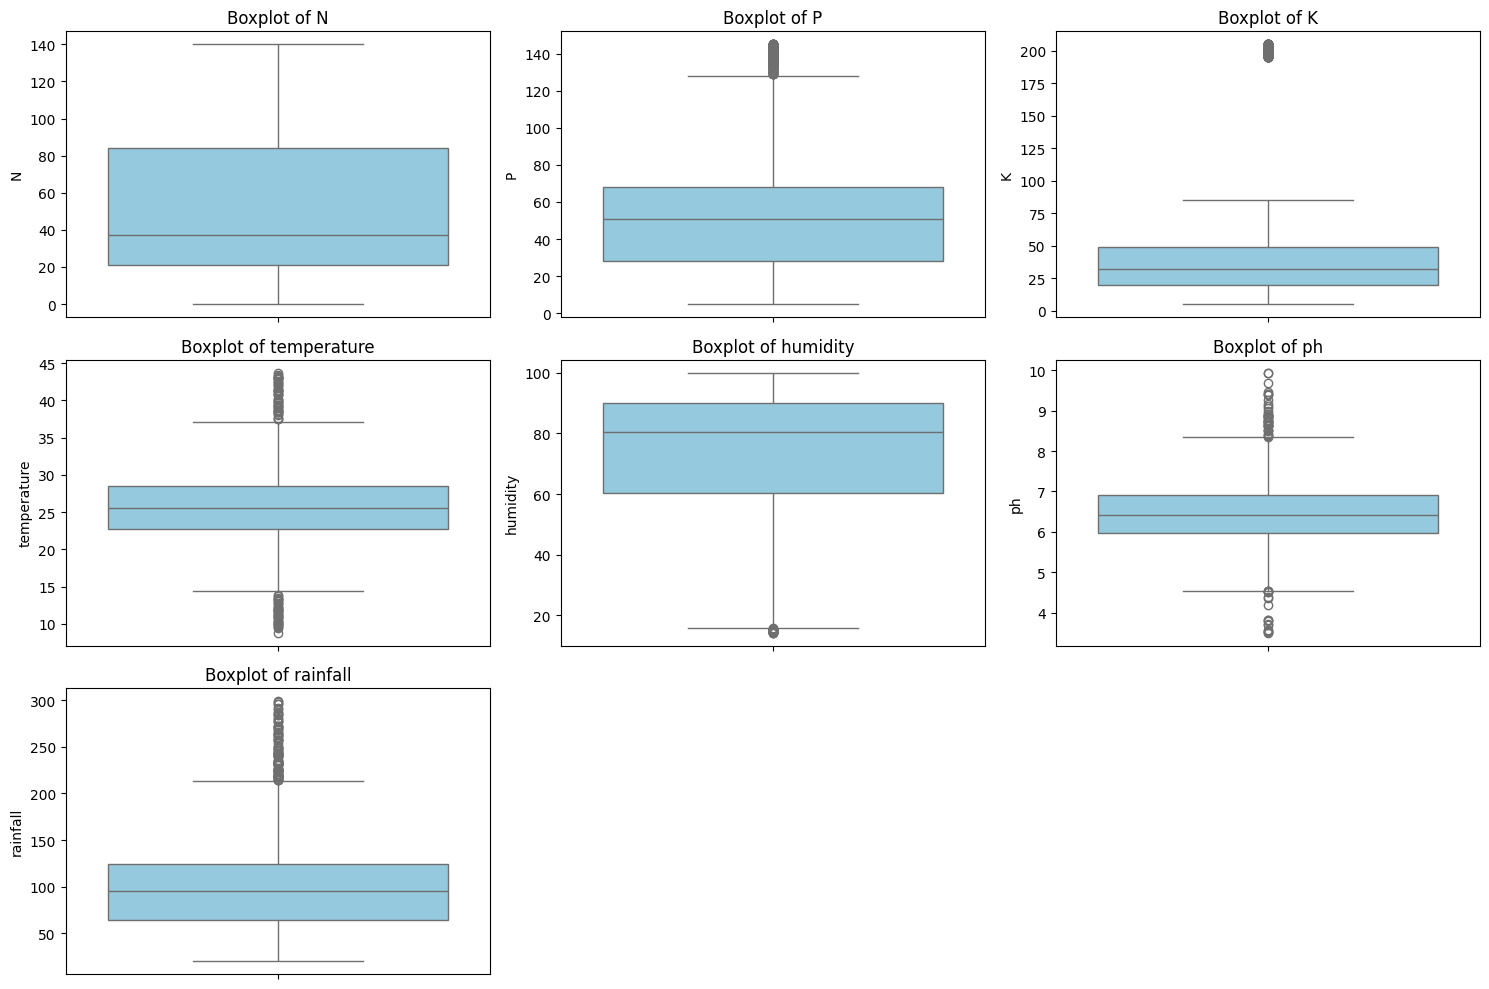

In [5]:
plt.figure(figsize=(15, 10))
features = df.drop('label', axis=1).columns
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[feature], color='skyblue')
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

# 3. Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan melihat distribusi data pada setiap fitur serta menganalisis korelasi antar variabel untuk mendapatkan wawasan (insight) yang berguna sebelum membangun model.

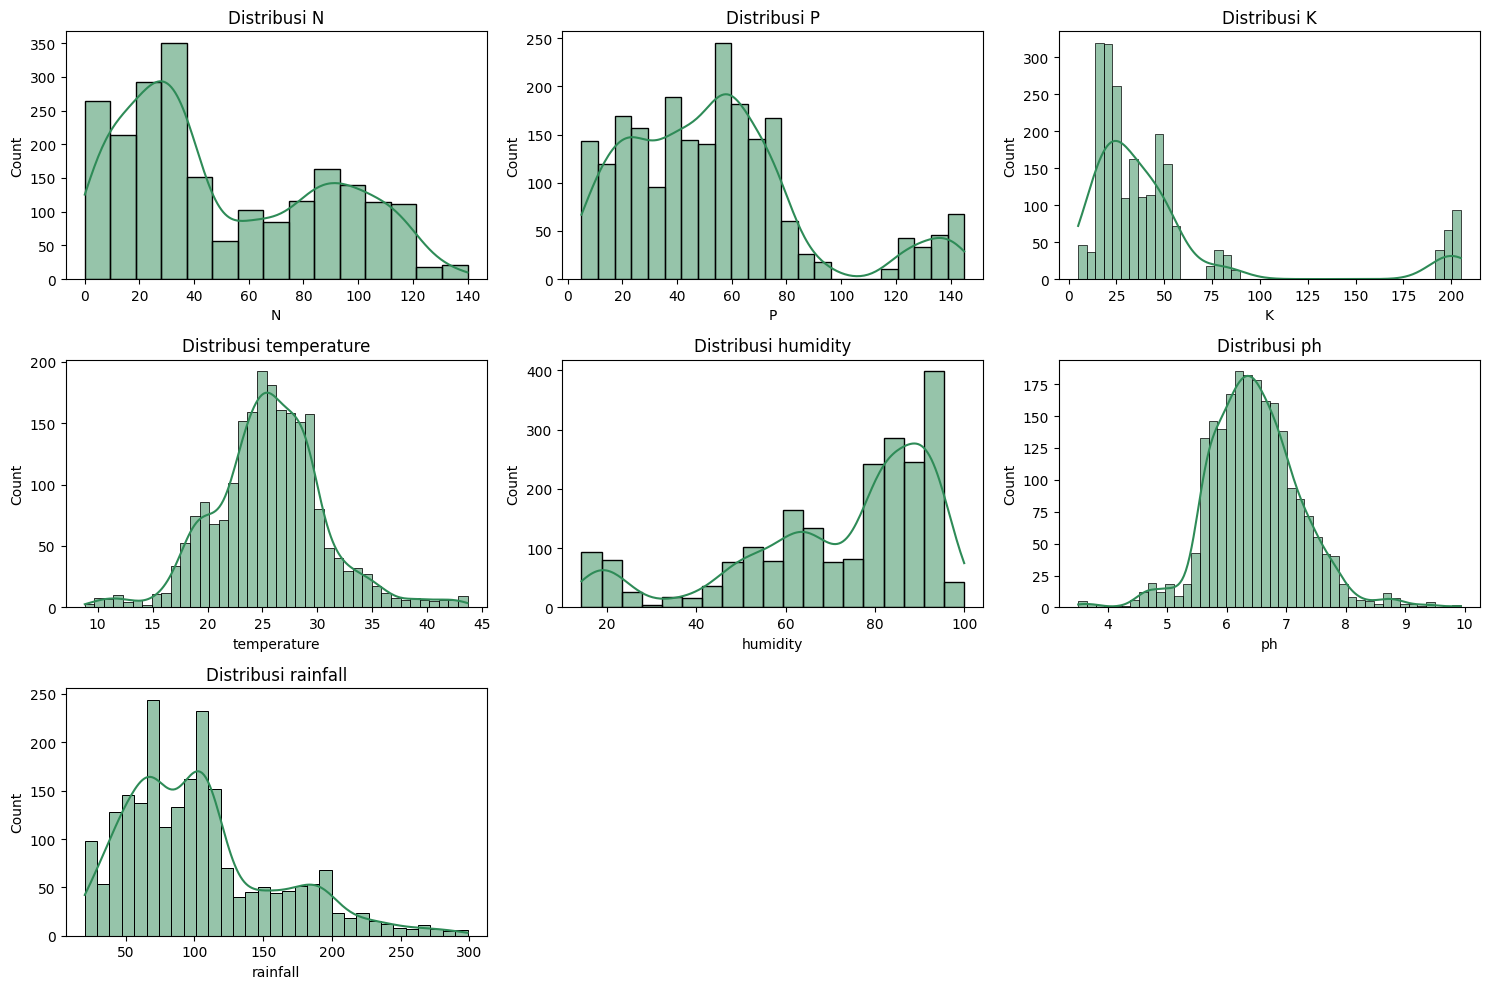

In [6]:
### Distribusi Data Fitur Numerik
plt.figure(figsize=(15, 10))
features = df.drop('label', axis=1).columns
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[feature], kde=True, color='seagreen')
    plt.title(f'Distribusi {feature}')
plt.tight_layout()
plt.show()

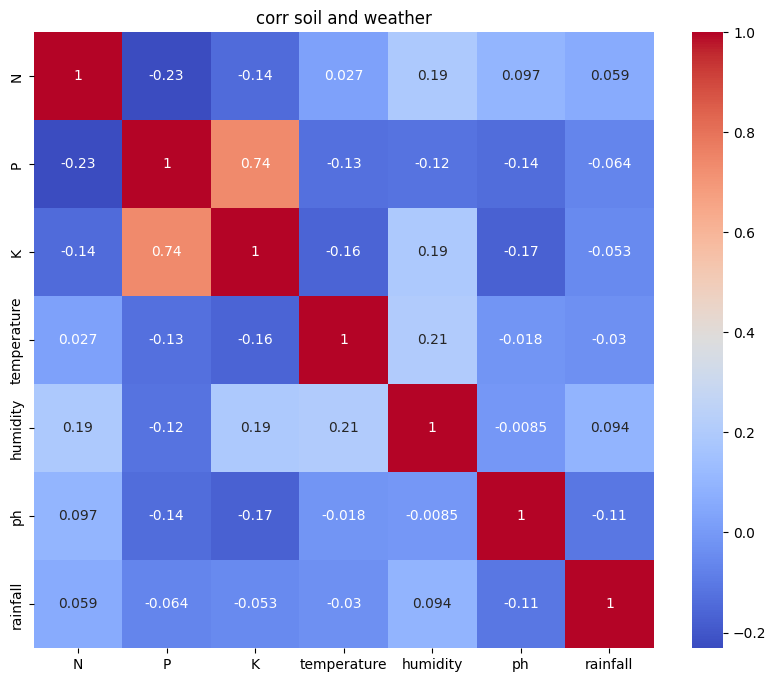

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('label',axis=1).corr(),annot=True,cmap='coolwarm')
plt.title("corr soil and weather")
plt.show()

### Insight dari Exploratory Data Analysis:
1. **Distribusi Fitur**: Sebagian besar fitur numerik (seperti suhu dan tipe tanah P, K) tidak berdistribusi normal sempurna dan ada yang berbentuk *skewed*. Curah hujan (rainfall) memiliki variance yang tinggi, menunjukkan bahwa jenis tanaman sangat bergantung pada kondisi hujan.
2. **Korelasi antar Variabel**: Jika kita melihat *Correlation Heatmap*, Phosphorous (P) dan Potassium (K) memiliki korelasi positif yang sangat tinggi. Ini masuk akal karena banyak pupuk yang menggabungkan kedua elemen tersebut dengan rasio tertentu.
3. **Tantangan Splitting**: Karena label berimbang dan fitur-fitur bervariasi nilainya, *Stratified Splitting* dan *Feature Scaling* sangat direkomendasikan untuk menghindari ketidakseimbangan data saat melatih model.

In [8]:
#split label dan fitur

X = df.drop('label',axis=1)

y = df['label']

In [9]:
#scaling biar seimbang
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#encode crop jadi integer etc. apel = 0
label_encode = LabelEncoder()
y_encoded = label_encode.fit_transform(y)

crop_dict=dict(zip(label_encode.classes_,label_encode.transform(label_encode.classes_)))
print(crop_dict)

{'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


# 4. Data Splitting, 5. Model Building, 6. Hyperparameter Tuning & 7. Evaluation
Sesuai dengan instruksi tugas, kita akan menggunakan 3 algoritma klasifikasi:
1. **Random Forest**
2. **Support Vector Machine (SVM)**
3. **K-Nearest Neighbors (KNN)**

Kita juga akan melakukan eksperimen **Data Splitting** dengan 3 rasio berbeda (90:10, 80:20, dan 70:30).
Untuk setiap kombinasi, kita akan melakukan **Hyperparameter Tuning** memanfaatkan `GridSearchCV`, mengevaluasi akurasi, dan menampilkan *Confusion Matrix*.

🔹 EKSPERIMEN DATA SPLITTING: 90:10 (Test Size: 0.1)
Jumlah Data Latih: 1980 | Jumlah Data Uji: 220

[+] Melatih dan Tuning Random Forest...
    Best Params: {'max_depth': 10, 'n_estimators': 50}
    Test Accuracy: 99.09%
    Waktu iterasi: 6.42 detik

[+] Melatih dan Tuning SVM...
    Best Params: {'C': 10, 'kernel': 'rbf'}
    Test Accuracy: 99.09%
    Waktu iterasi: 0.70 detik

[+] Melatih dan Tuning KNN...
    Best Params: {'n_neighbors': 3, 'weights': 'distance'}
    Test Accuracy: 98.64%
    Waktu iterasi: 0.08 detik



🔹 EKSPERIMEN DATA SPLITTING: 80:20 (Test Size: 0.2)
Jumlah Data Latih: 1760 | Jumlah Data Uji: 440

[+] Melatih dan Tuning Random Forest...
    Best Params: {'max_depth': None, 'n_estimators': 50}
    Test Accuracy: 99.55%
    Waktu iterasi: 2.48 detik

    --> Confusion Matrix (Random Forest - 80:20):


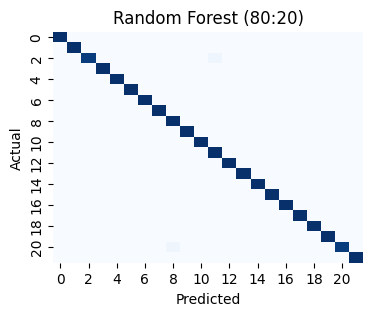



[+] Melatih dan Tuning SVM...
    Best Params: {'C': 10, 'kernel': 'rbf'}
    Test Accuracy: 98.86%
    Waktu iterasi: 0.63 detik

    --> Confusion Matrix (SVM - 80:20):


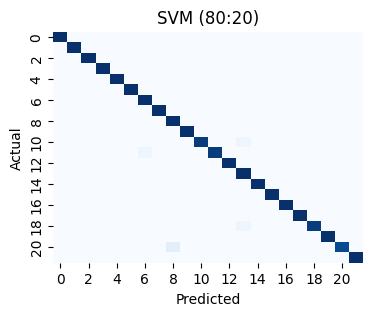



[+] Melatih dan Tuning KNN...
    Best Params: {'n_neighbors': 3, 'weights': 'distance'}
    Test Accuracy: 97.50%
    Waktu iterasi: 0.08 detik

    --> Confusion Matrix (KNN - 80:20):


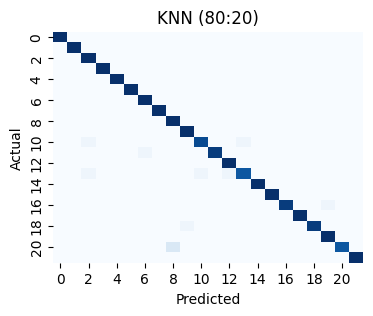





🔹 EKSPERIMEN DATA SPLITTING: 70:30 (Test Size: 0.3)
Jumlah Data Latih: 1540 | Jumlah Data Uji: 660

[+] Melatih dan Tuning Random Forest...
    Best Params: {'max_depth': None, 'n_estimators': 50}
    Test Accuracy: 99.39%
    Waktu iterasi: 2.29 detik

[+] Melatih dan Tuning SVM...
    Best Params: {'C': 10, 'kernel': 'rbf'}
    Test Accuracy: 99.24%
    Waktu iterasi: 0.58 detik

[+] Melatih dan Tuning KNN...
    Best Params: {'n_neighbors': 3, 'weights': 'distance'}
    Test Accuracy: 97.73%
    Waktu iterasi: 0.07 detik





In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import time

# 1. Definisi model dan parameter grid yang akan diuji
models_params = {
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
    ),
    'SVM': (
        SVC(random_state=42),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    )
}

# 2. Daftar variasi rasio splitting (test_size)
test_sizes = [0.1, 0.2, 0.3]  # 90:10, 80:20, 70:30
str_ratios = ['90:10', '80:20', '70:30']

results = []  # Untuk menyimpan hasil perbandingan
best_global_acc = 0
best_global_model = None
best_global_name = ''
best_global_ratio = ''

for test_size, ratio_name in zip(test_sizes, str_ratios):
    print("="*60)
    print(f"🔹 EKSPERIMEN DATA SPLITTING: {ratio_name} (Test Size: {test_size})")
    print("="*60)
    
    # Data Splitting
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=test_size, random_state=42, stratify=y_encoded
    )
    print(f"Jumlah Data Latih: {X_train.shape[0]} | Jumlah Data Uji: {X_test.shape[0]}\n")
    
    for model_name, (model, param_grid) in models_params.items():
        print(f"[+] Melatih dan Tuning {model_name}...")
        start_time = time.time()
        
        # Grid Search CV
        grid_search = GridSearchCV(
            estimator=model, 
            param_grid=param_grid, 
            cv=5, 
            n_jobs=-1
        )
        grid_search.fit(X_train, y_train)
        
        best_model = grid_search.best_estimator_
        
        # Evaluasi pada data uji
        y_pred = best_model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        # Simpan hasil
        if acc > best_global_acc:
            best_global_acc = acc
            best_global_model = best_model
            best_global_name = model_name
            best_global_ratio = ratio_name
        
        results.append({
            'Model': model_name,
            'Splitting Ratio': ratio_name,
            'Best Params': str(grid_search.best_params_),
            'Accuracy': acc
        })
        
        print(f"    Best Params: {grid_search.best_params_}")
        print(f"    Test Accuracy: {acc * 100:.2f}%")
        print(f"    Waktu iterasi: {time.time() - start_time:.2f} detik\n")
        
        # Menampilkan Confusion Matrix (Hanya untuk 80:20 agar tidak terlalu panjang)
        if ratio_name == '80:20':
            print(f"    --> Confusion Matrix ({model_name} - 80:20):")
            cm = confusion_matrix(y_test, y_pred)
            plt.figure(figsize=(4, 3))
            sns.heatmap(cm, annot=False, cmap='Blues', cbar=False)
            plt.title(f'{model_name} (80:20)')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.show()
            print("\n")
    print("\n")

# 8. Model Comparison
Berikut adalah tabel perbandingan performa akurasi setiap model di masing-masing konfigurasi *data splitting*.
Serta Visualisasi *Bar Chart* untuk memudahkan interpretasi.

,Model,Splitting Ratio,Best Params,Accuracy
3,Random Forest,80:20,"{'max_depth': None, 'n_estimators': 50}",0.995455
6,Random Forest,70:30,"{'max_depth': None, 'n_estimators': 50}",0.993939
7,SVM,70:30,"{'C': 10, 'kernel': 'rbf'}",0.992424
0,Random Forest,90:10,"{'max_depth': 10, 'n_estimators': 50}",0.990909
1,SVM,90:10,"{'C': 10, 'kernel': 'rbf'}",0.990909
4,SVM,80:20,"{'C': 10, 'kernel': 'rbf'}",0.988636
2,KNN,90:10,"{'n_neighbors': 3, 'weights': 'distance'}",0.986364
8,KNN,70:30,"{'n_neighbors': 3, 'weights': 'distance'}",0.977273
5,KNN,80:20,"{'n_neighbors': 3, 'weights': 'distance'}",0.975000


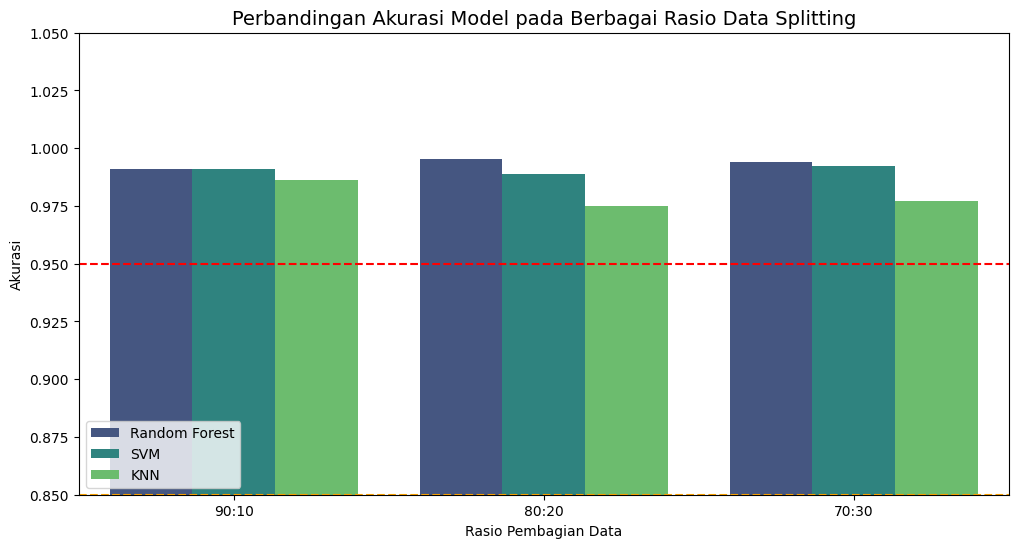

In [11]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Accuracy', ascending=False))

# Visualisasi Perbandingan
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Splitting Ratio', y='Accuracy', hue='Model', palette='viridis')
plt.title('Perbandingan Akurasi Model pada Berbagai Rasio Data Splitting', fontsize=14)
plt.ylim(0.85, 1.05)  # Zoom in akurasi karena hasilnya pasti tinggi
plt.legend(loc='lower left')
plt.axhline(0.95, color='red', linestyle='--', label='Target 95%')
plt.axhline(0.85, color='orange', linestyle='--', label='Target 85%')
plt.ylabel('Akurasi')
plt.xlabel('Rasio Pembagian Data')
plt.show()

# 9. Export Best Model
Setelah membandingkan performa model-model di atas, kita akan menyimpan (export) model terbaik beserta `Scaler` dan `LabelEncoder` yang dibutuhkan untuk memprediksi data input baru dari pengguna.

In [12]:
import joblib

print("="*60)
print(f"🏅 MODEL TERBAIK:\nNama Model: {best_global_name}\nRasio Splitting: {best_global_ratio}\nAkurasi: {best_global_acc*100:.2f}%")
print("="*60)

# 1. Menyimpan Model Terbaik ke .pkl
joblib.dump(best_global_model, 'best_crop_model.pkl')
print("[+] Berhasil menyimpan model: 'best_crop_model.pkl'")

# 2. Menyimpan Scaler untuk standarisasi input baru di kemudian hari
joblib.dump(scaler, 'scaler.pkl')
print("[+] Berhasil menyimpan scaler: 'scaler.pkl'")

# 3. Menyimpan LabelEncoder untuk melakukan decode prediksi ke nama tanaman
joblib.dump(label_encode, 'label_encoder.pkl')
print("[+] Berhasil menyimpan label encoder: 'label_encoder.pkl'")

print("\n🚀 Semua file yang dibutuhkan untuk tahap deployment/prediksi telah disimpan dalam bentuk '.pkl'!")

🏅 MODEL TERBAIK:
Nama Model: Random Forest
Rasio Splitting: 80:20
Akurasi: 99.55%
[+] Berhasil menyimpan model: 'best_crop_model.pkl'
[+] Berhasil menyimpan scaler: 'scaler.pkl'
[+] Berhasil menyimpan label encoder: 'label_encoder.pkl'

🚀 Semua file yang dibutuhkan untuk tahap deployment/prediksi telah disimpan dalam bentuk '.pkl'!
